In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.base import clone

import warnings
warnings.filterwarnings("ignore")

In [2]:
columns = ["label", "lepton_pT", "lepton_eta", "lepton_phi", "missing_energy_magnitude", "missing_energy_phi", "jet_1_pt", "jet_1_eta", 
           "jet_1_phi", "jet_1_b_tag", "jet_2_pt", "jet_2_eta", "jet_2_phi", "jet_2_b_tag", "jet_3_pt", "jet_3_eta", "jet_3_phi", 
           "jet_3_b_tag", "jet_4_pt", "jet_4_eta", "jet_4_phi", "jet_4_b_tag", "m_jj", "m_jjj", "m_lv", "m_jlv", "m_bb", "m_wbb", "m_wwbb" ]

In [3]:
df = pd.read_csv("HIGGS.csv", compression="gzip", header=None, names=columns)

In [4]:
df.head()

,label,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet_1_pt,jet_1_eta,jet_1_phi,jet_1_b_tag,...,jet_4_eta,jet_4_phi,jet_4_b_tag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,1.0,0.869293,-0.635082,0.225690,0.327470,-0.689993,0.754202,-0.248573,-1.092064,0.000000,...,-0.010455,-0.045767,3.101961,1.353760,0.979563,0.978076,0.920005,0.721657,0.988751,0.876678
1,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
2,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
3,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
4,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487


In [5]:
df.shape

(11000000, 29)

In [6]:
df = df.sample(n=100000, random_state=23)

In [7]:
df.shape

(100000, 29)

In [8]:
df["label"].value_counts()

label
1.0    53134
0.0    46866
Name: count, dtype: int64

In [9]:
df.isnull().sum()

label                       0
lepton_pT                   0
lepton_eta                  0
lepton_phi                  0
missing_energy_magnitude    0
missing_energy_phi          0
jet_1_pt                    0
jet_1_eta                   0
jet_1_phi                   0
jet_1_b_tag                 0
jet_2_pt                    0
jet_2_eta                   0
jet_2_phi                   0
jet_2_b_tag                 0
jet_3_pt                    0
jet_3_eta                   0
jet_3_phi                   0
jet_3_b_tag                 0
jet_4_pt                    0
jet_4_eta                   0
jet_4_phi                   0
jet_4_b_tag                 0
m_jj                        0
m_jjj                       0
m_lv                        0
m_jlv                       0
m_bb                        0
m_wbb                       0
m_wwbb                      0
dtype: int64

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 100000 entries, 8072155 to 3132601
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   label                     100000 non-null  float64
 1   lepton_pT                 100000 non-null  float64
 2   lepton_eta                100000 non-null  float64
 3   lepton_phi                100000 non-null  float64
 4   missing_energy_magnitude  100000 non-null  float64
 5   missing_energy_phi        100000 non-null  float64
 6   jet_1_pt                  100000 non-null  float64
 7   jet_1_eta                 100000 non-null  float64
 8   jet_1_phi                 100000 non-null  float64
 9   jet_1_b_tag               100000 non-null  float64
 10  jet_2_pt                  100000 non-null  float64
 11  jet_2_eta                 100000 non-null  float64
 12  jet_2_phi                 100000 non-null  float64
 13  jet_2_b_tag               100000 non-null  float64
 1

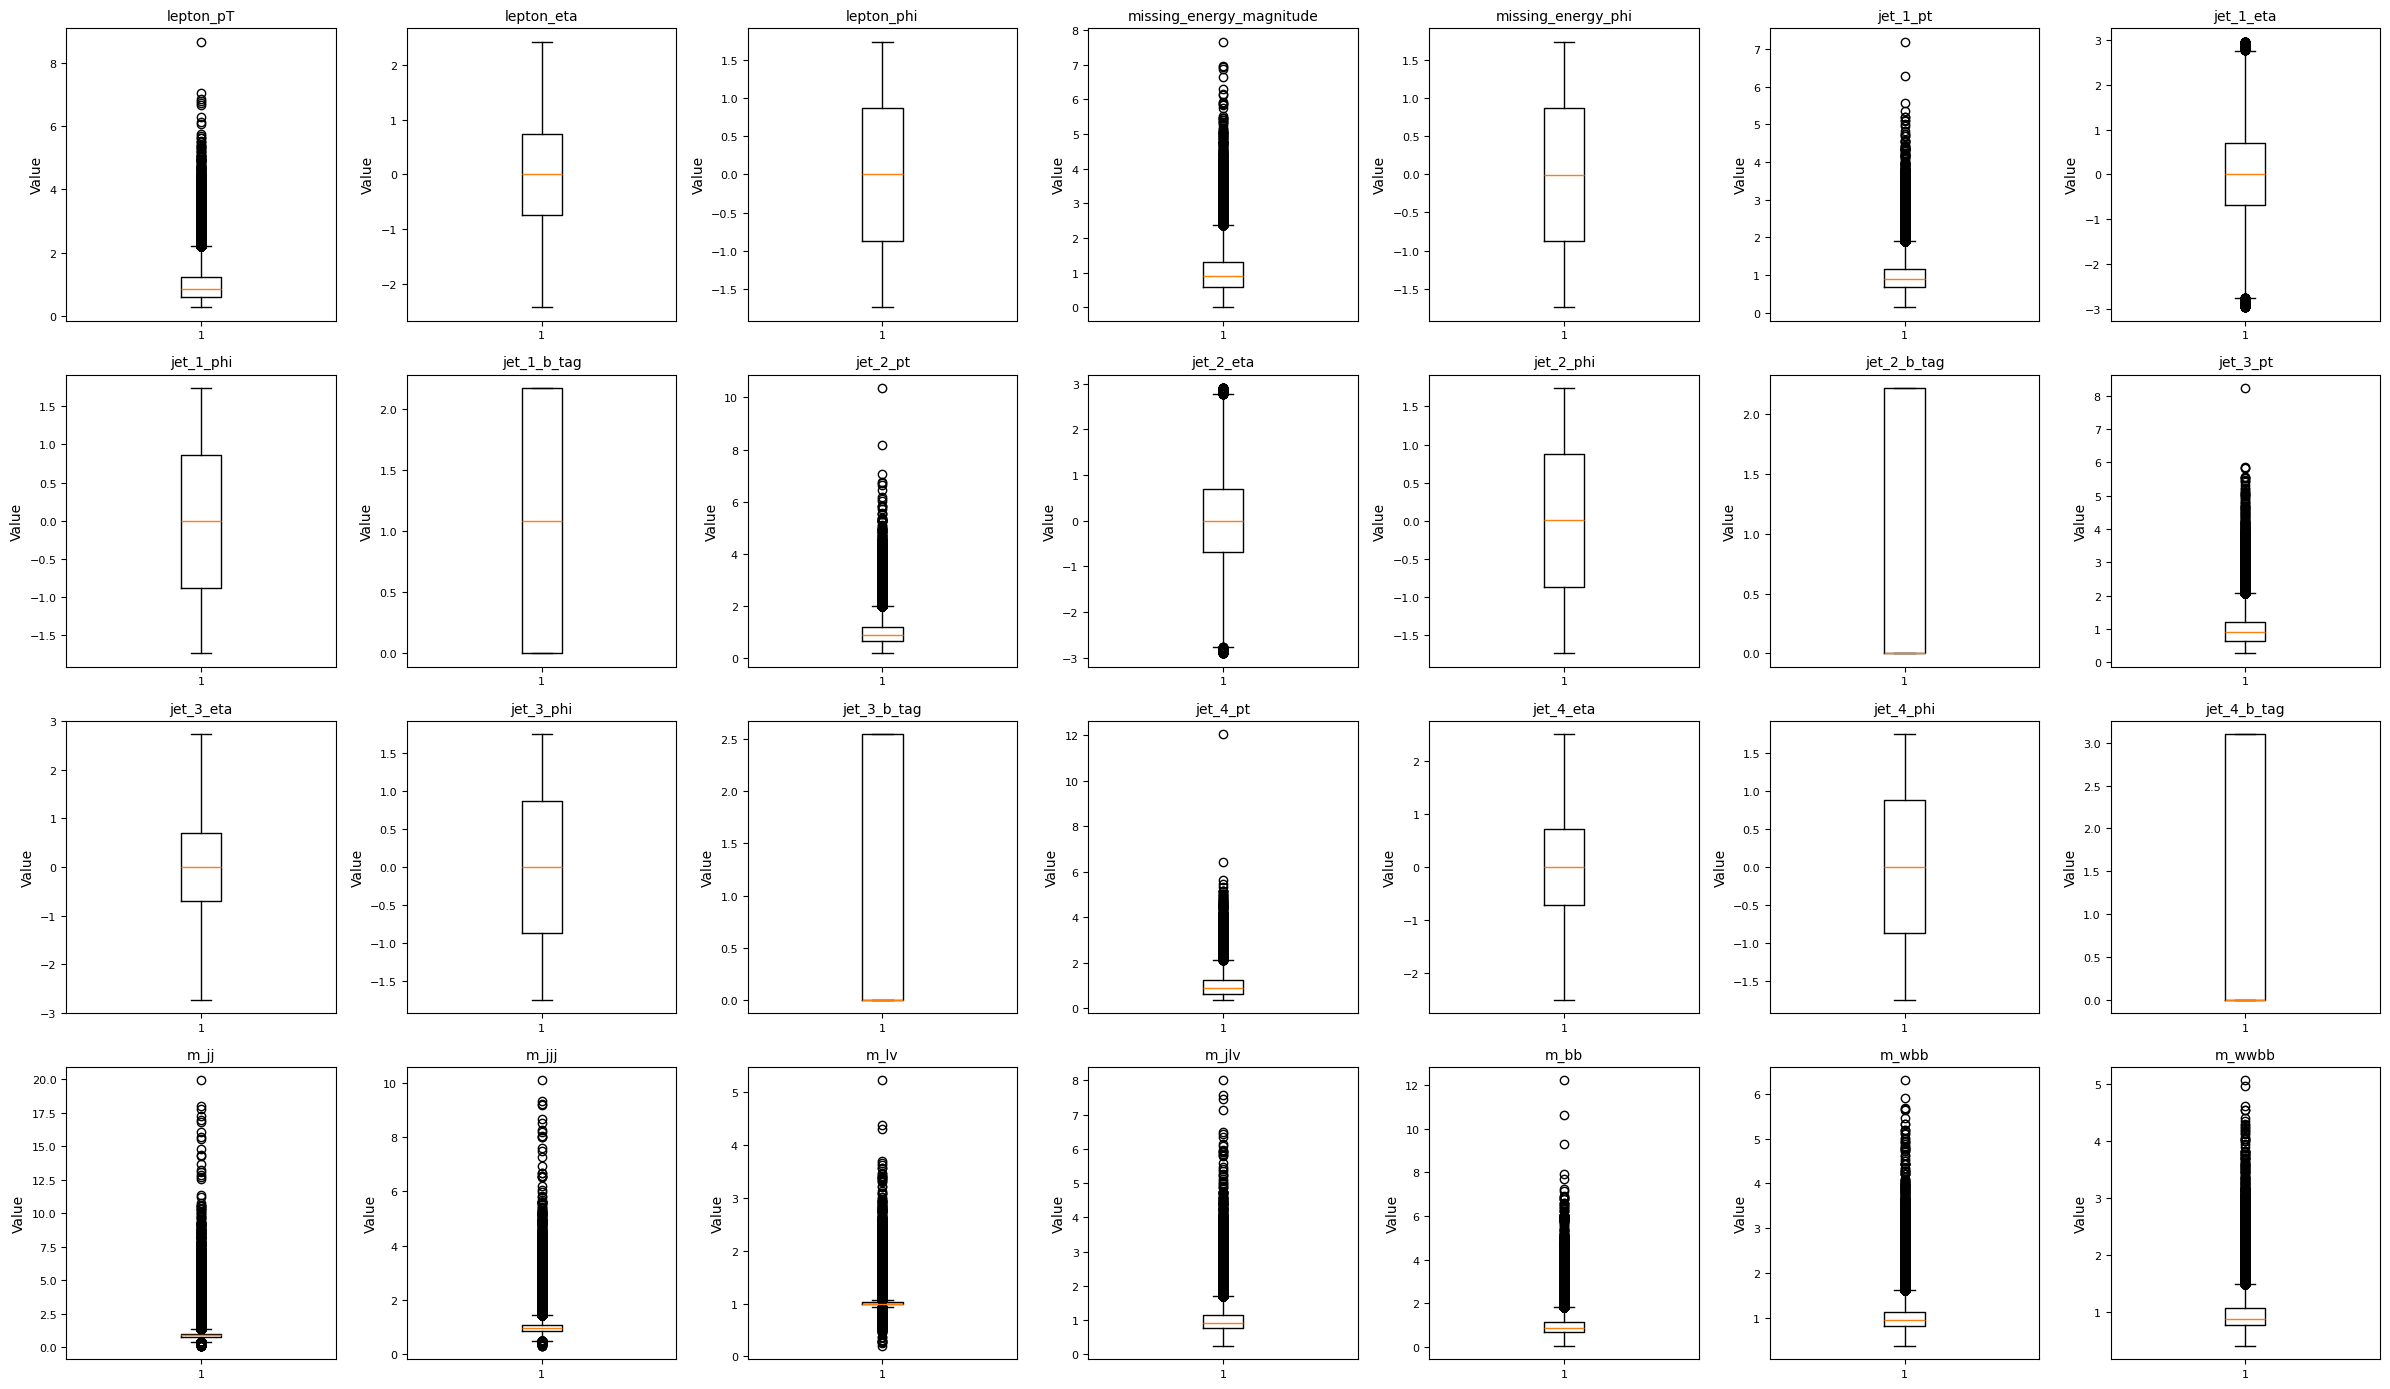

In [11]:
feature_cols = [col for col in df.columns if col != "label"]

fig, axes = plt.subplots(4, 7, figsize=(24, 14))
axes = axes.ravel()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, showfliers=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Value")
    axes[i].tick_params(axis="x", labelsize=8)
    axes[i].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

In [12]:
Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = ~((df[feature_cols] < lower_bound) | 
         (df[feature_cols] > upper_bound)).any(axis=1)

df_clean = df[mask].reset_index(drop=True)

print("Before removing outliers:", df.shape)
print("After removing outliers:", df_clean.shape)
print("Removed rows:", df.shape[0] - df_clean.shape[0])

Before removing outliers: (100000, 29)
After removing outliers: (53028, 29)
Removed rows: 46972


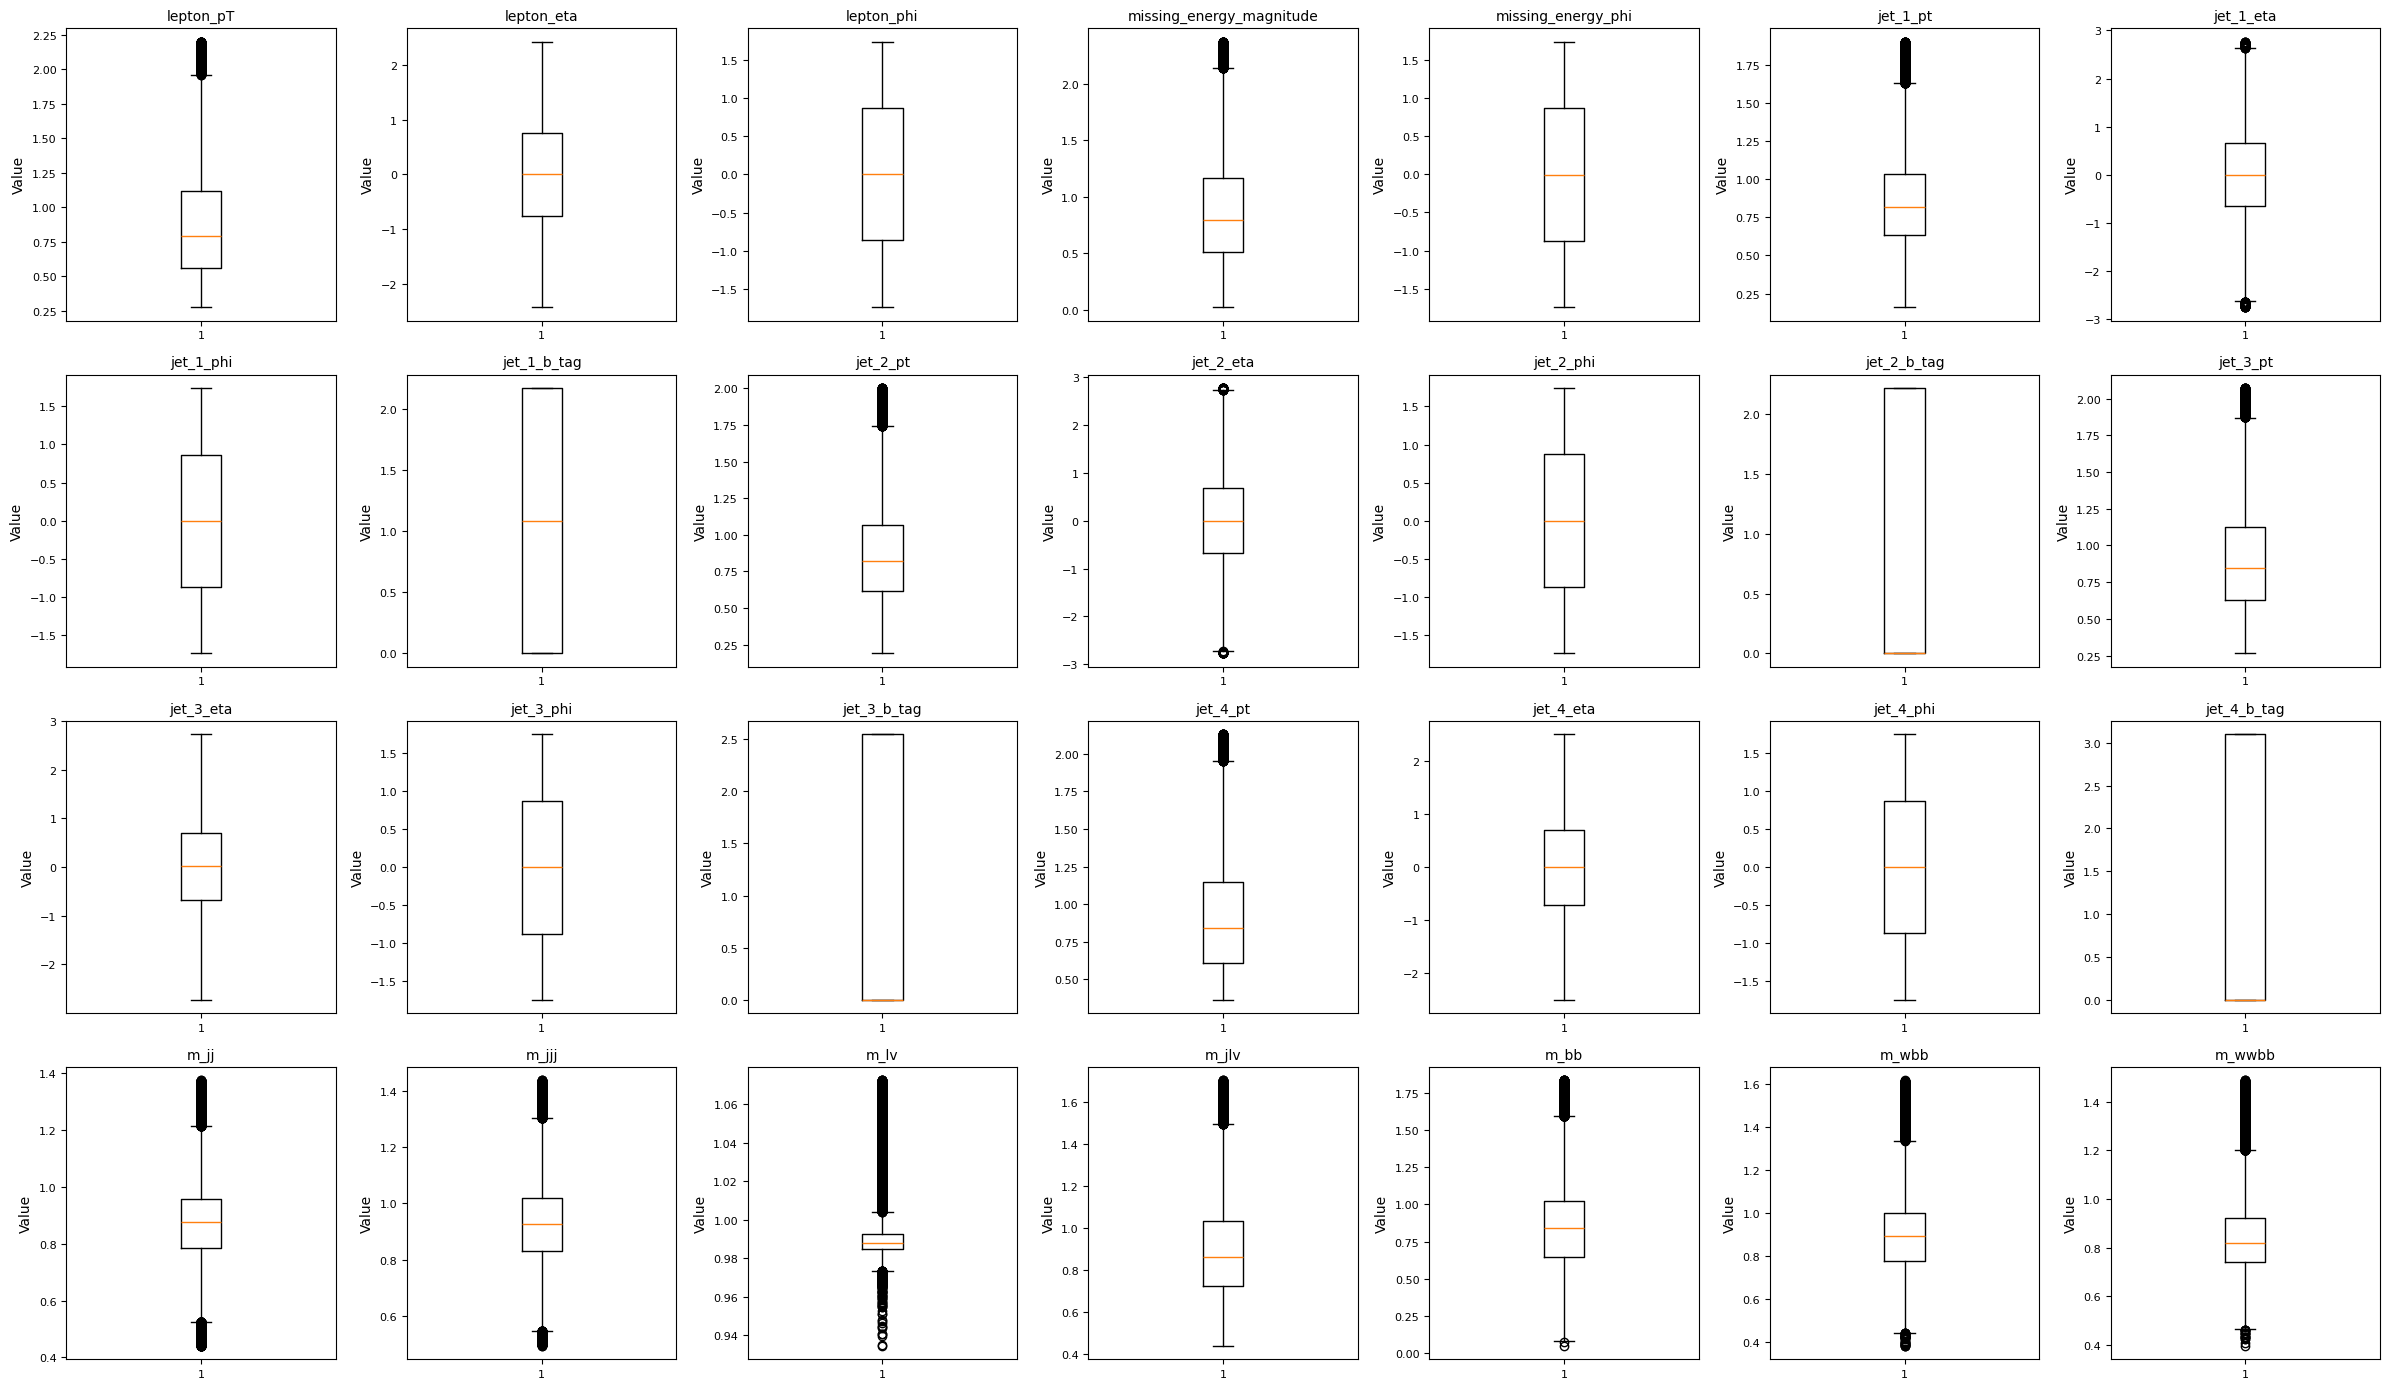

In [13]:
fig, axes = plt.subplots(4, 7, figsize=(24, 14))
axes = axes.ravel()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df_clean[col].dropna(), vert=True, showfliers=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Value")
    axes[i].tick_params(axis="x", labelsize=8)
    axes[i].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

In [ ]:
df_clean.head()

,label,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet_1_pt,jet_1_eta,jet_1_phi,jet_1_b_tag,...,jet_4_eta,jet_4_phi,jet_4_b_tag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,0.0,0.278738,0.418702,0.618445,0.669443,0.391381,0.372078,0.413317,0.029130,0.0,...,0.983325,0.880456,0.0,0.518916,0.500996,0.704092,0.229034,0.625483,0.333585,0.359899
1,0.0,0.017576,0.638967,0.120818,0.672247,0.522571,0.404875,0.843324,0.474517,0.0,...,0.677005,0.780968,1.0,0.755573,0.549723,0.403578,0.355834,0.385567,0.478148,0.473634
2,1.0,0.438153,0.536444,0.388241,0.297226,0.656916,0.443830,0.272254,0.179237,0.0,...,0.269468,0.922957,0.0,0.590414,0.659510,0.386290,0.287477,0.381175,0.398341,0.406531
3,0.0,0.104313,0.215058,0.452709,0.248670,0.358561,0.722573,0.260409,0.779854,0.0,...,0.710188,0.256280,1.0,0.448857,0.480649,0.472957,0.317292,0.758965,0.854203,0.725618
4,1.0,0.186301,0.682619,0.347969,0.256199,0.661988,0.474995,0.663855,0.996498,0.0,...,0.330665,0.344785,1.0,0.388642,0.582363,0.376710,0.188985,0.490206,0.414387,0.345653


In [15]:
def flowchart_A(df):

    X = df.drop("label", axis=1)
    y = df["label"].astype(int)

    feature_names = X.columns

    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    results = []

    models = {
        "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),

        "SVM": SVC(C=1, kernel="rbf", probability=True),

        "MLP": MLPClassifier(hidden_layer_sizes=(50,), activation="relu", max_iter=300, random_state=42),

        "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1)
    }


    feature_method = "anova"

    for outer_fold, (train_index, test_index) in enumerate(outer_cv.split(X, y), start=1):

        print("\nOuter Fold:", outer_fold)

        X_train_val = X.iloc[train_index]
        X_test = X.iloc[test_index]

        y_train_val = y.iloc[train_index]
        y_test = y.iloc[test_index]

        for model_name, base_model in models.items():

            print("Model:", model_name)

            inner_scores = []

            for inner_train_index, inner_val_index in inner_cv.split(X_train_val, y_train_val):

                X_inner_train = X_train_val.iloc[inner_train_index]
                X_inner_val = X_train_val.iloc[inner_val_index]

                y_inner_train = y_train_val.iloc[inner_train_index]
                y_inner_val = y_train_val.iloc[inner_val_index]

                scaler = MinMaxScaler()
                X_inner_train_scaled = scaler.fit_transform(X_inner_train)
                X_inner_val_scaled = scaler.transform(X_inner_val)

                selector = SelectKBest(score_func=f_classif, k=15)

                X_inner_train_selected = selector.fit_transform(X_inner_train_scaled, y_inner_train)
                X_inner_val_selected = selector.transform(X_inner_val_scaled)

                model = clone(base_model)
                model.fit(X_inner_train_selected, y_inner_train)

                y_val_pred = model.predict(X_inner_val_selected)
                acc = accuracy_score(y_inner_val, y_val_pred)

                inner_scores.append(acc)

            mean_inner_acc = np.mean(inner_scores)

            print(feature_method, "inner accuracy:", mean_inner_acc)

            scaler = MinMaxScaler()
            X_train_val_scaled = scaler.fit_transform(X_train_val)
            X_test_scaled = scaler.transform(X_test)

            selector = SelectKBest(score_func=f_classif, k=15)

            X_train_val_selected = selector.fit_transform(X_train_val_scaled, y_train_val)
            X_test_selected = selector.transform(X_test_scaled)

            selected_features = feature_names[selector.get_support()]

            final_model = clone(base_model)
            final_model.fit(X_train_val_selected, y_train_val)

            y_pred = final_model.predict(X_test_selected)

            if hasattr(final_model, "predict_proba"):
                y_score = final_model.predict_proba(X_test_selected)[:, 1]
            else:
                y_score = final_model.decision_function(X_test_selected)

            acc = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            auc = roc_auc_score(y_test, y_score)

            results.append({"outer_fold": outer_fold, "model": model_name, "feature_selection": feature_method,
                "inner_accuracy": mean_inner_acc, "test_accuracy": acc, "precision": precision,
                "recall": recall, "f1_score": f1, "roc_auc": auc, "selected_features": list(selected_features)})

            print("Test Accuracy:", acc)
            print("----------------------")

    results_df = pd.DataFrame(results)

    return results_df



In [16]:
results_A = flowchart_A(df_clean)
results_A



Outer Fold: 1
Model: KNN
anova inner accuracy: 0.645608619273638
Test Accuracy: 0.6487837073354705
----------------------
Model: SVM
anova inner accuracy: 0.6962190104571188
Test Accuracy: 0.7031868753535735
----------------------
Model: MLP
anova inner accuracy: 0.7120833282071476
Test Accuracy: 0.7237412785215915
----------------------
Model: XGBoost
anova inner accuracy: 0.7093960816470183
Test Accuracy: 0.7211955496888554
----------------------

Outer Fold: 2
Model: KNN
anova inner accuracy: 0.6439111766551603
Test Accuracy: 0.6452008297190269
----------------------
Model: SVM
anova inner accuracy: 0.6981282120554484
Test Accuracy: 0.6939468225532718
----------------------
Model: MLP
anova inner accuracy: 0.7163029141973872
Test Accuracy: 0.7132755044314539
----------------------
Model: XGBoost
anova inner accuracy: 0.7101739882434807
Test Accuracy: 0.7119554968885536
----------------------

Outer Fold: 3
Model: KNN
anova inner accuracy: 0.6332327734071558
Test Accuracy: 0.6432208

,outer_fold,model,feature_selection,inner_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,selected_features
0,1,KNN,anova,0.645609,0.648784,0.668250,0.705831,0.686527,0.692958,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
1,1,SVM,anova,0.696219,0.703187,0.701424,0.792698,0.744273,0.766571,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
2,1,MLP,anova,0.712083,0.723741,0.735649,0.769510,0.752199,0.793814,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
3,1,XGBoost,anova,0.709396,0.721196,0.739803,0.753245,0.746463,0.792490,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
4,2,KNN,anova,0.643911,0.645201,0.663532,0.707958,0.685026,0.686759,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
5,2,SVM,anova,0.698128,0.693947,0.695948,0.778547,0.734934,0.757339,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
6,2,MLP,anova,0.716303,0.713276,0.726626,0.759689,0.742789,0.785575,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
7,2,XGBoost,anova,0.710174,0.711955,0.732548,0.742561,0.737520,0.781362,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
8,3,KNN,anova,0.633233,0.643221,0.661750,0.706401,0.683347,0.681216,"[missing_energy_magnitude, jet_1_pt, jet_1_phi..."
9,3,SVM,anova,0.696596,0.700453,0.706031,0.771626,0.737373,0.764973,"[missing_energy_magnitude, jet_1_pt, jet_1_phi..."


In [17]:
summary_A = results_A.groupby("model").agg(
    test_accuracy=("test_accuracy", "mean"),
    precision=("precision", "mean"),
    recall=("recall", "mean"),
    f1_score=("f1_score", "mean"),
    roc_auc_mean=("roc_auc", "mean"),
    roc_auc_std=("roc_auc", "std")
)

top_5_results_A = results_A.sort_values("roc_auc", ascending=False).head(5)

top_5_results_A


,test_accuracy,precision,recall,f1_score,roc_auc
model,,,,,
MLP,0.717904,0.732610,0.760079,0.745872,0.791649
XGBoost,0.717828,0.738350,0.746860,0.742548,0.790042
SVM,0.701611,0.703672,0.781639,0.740580,0.765837
KNN,0.647960,0.667230,0.706267,0.686184,0.691300


In [19]:
def flowchart_B(df):

    X = df.drop("label", axis=1)
    y = df["label"].astype(int)

    feature_names = X.columns

    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    results = []

    base_models = {
        "KNN": KNeighborsClassifier(n_jobs=-1),
        "SVM": SVC(probability=True),
        "MLP": MLPClassifier(max_iter=300, random_state=42),
        "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1)
    }

    param_grids = {
        "KNN": [{"n_neighbors": 3}, {"n_neighbors": 4}, {"n_neighbors": 5}, {"n_neighbors": 6}, {"n_neighbors": 7},
            {"n_neighbors": 8}, {"n_neighbors": 9}, {"n_neighbors": 10}, {"n_neighbors": 11}],

        "SVM": [{"C": 0.1, "kernel": "linear"}, {"C": 0.1, "kernel": "rbf"}, {"C": 1, "kernel": "linear"},
            {"C": 1, "kernel": "rbf"}, {"C": 10, "kernel": "linear"}, {"C": 10, "kernel": "rbf"}],

        "MLP": [{"hidden_layer_sizes": (50,), "activation": "relu"}, {"hidden_layer_sizes": (50,), "activation": "tanh"},
            {"hidden_layer_sizes": (100,), "activation": "relu"}, {"hidden_layer_sizes": (100,), "activation": "tanh"}],

        "XGBoost": [{}]
    }

    feature_method = "anova"

    for outer_fold, (train_index, test_index) in enumerate(outer_cv.split(X, y), start=1):

        print("\nOuter Fold:", outer_fold)

        X_train_val = X.iloc[train_index]
        X_test = X.iloc[test_index]

        y_train_val = y.iloc[train_index]
        y_test = y.iloc[test_index]

        scaler = MinMaxScaler()
        X_train_val_scaled = scaler.fit_transform(X_train_val)
        X_test_scaled = scaler.transform(X_test)

        selector = SelectKBest(score_func=f_classif, k=15)

        X_train_val_selected = selector.fit_transform(X_train_val_scaled, y_train_val)
        X_test_selected = selector.transform(X_test_scaled)

        selected_features = feature_names[selector.get_support()]

        for model_name in base_models:

            print("Model:", model_name)

            best_score = 0
            best_params = None

            for params in param_grids[model_name]:

                inner_scores = []

                for inner_train_index, inner_val_index in inner_cv.split(X_train_val, y_train_val):

                    X_inner_train = X_train_val.iloc[inner_train_index]
                    X_inner_val = X_train_val.iloc[inner_val_index]

                    y_inner_train = y_train_val.iloc[inner_train_index]
                    y_inner_val = y_train_val.iloc[inner_val_index]

                    inner_scaler = MinMaxScaler()
                    X_inner_train_scaled = inner_scaler.fit_transform(X_inner_train)
                    X_inner_val_scaled = inner_scaler.transform(X_inner_val)

                    inner_selector = SelectKBest(score_func=f_classif, k=15)
                    X_inner_train_selected = inner_selector.fit_transform(X_inner_train_scaled, y_inner_train)
                    X_inner_val_selected = inner_selector.transform(X_inner_val_scaled)

                    model = clone(base_models[model_name])
                    model.set_params(**params)

                    model.fit(X_inner_train_selected, y_inner_train)

                    y_val_pred = model.predict(X_inner_val_selected)
                    acc = accuracy_score(y_inner_val, y_val_pred)

                    inner_scores.append(acc)

                mean_acc = np.mean(inner_scores)
                print(params, "inner accuracy:", mean_acc)

                if mean_acc > best_score:
                    best_score = mean_acc
                    best_params = params

            if model_name == "XGBoost":
                print("Best params: default")
            else:
                print("Best params:", best_params)

            final_model = clone(base_models[model_name])
            final_model.set_params(**best_params)

            final_model.fit(X_train_val_selected, y_train_val)

            y_pred = final_model.predict(X_test_selected)
            y_score = final_model.predict_proba(X_test_selected)[:, 1]

            acc = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            auc_value = roc_auc_score(y_test, y_score)

            if model_name == "XGBoost":
                best_params_for_table = "default"
            else:
                best_params_for_table = best_params

            results.append({"outer_fold": outer_fold, "model": model_name, "feature_selection": feature_method,
                "best_params": best_params_for_table, "inner_accuracy": best_score, "test_accuracy": acc,
                "precision": precision, "recall": recall, "f1_score": f1, "roc_auc": auc_value, "selected_features": list(selected_features)})

            print("Test Accuracy:", acc)
            print("----------------------")

    return pd.DataFrame(results)



In [20]:
results_B = flowchart_B(df_clean)

results_B



Outer Fold: 1
Model: KNN
{'n_neighbors': 3} inner accuracy: 0.6371930844270947
{'n_neighbors': 4} inner accuracy: 0.631512050403925
{'n_neighbors': 5} inner accuracy: 0.6471407219823279
{'n_neighbors': 6} inner accuracy: 0.6415539597642268
{'n_neighbors': 7} inner accuracy: 0.6532696112610846
{'n_neighbors': 8} inner accuracy: 0.6489322130208718
{'n_neighbors': 9} inner accuracy: 0.6562397132456738
{'n_neighbors': 10} inner accuracy: 0.6548017956553351
{'n_neighbors': 11} inner accuracy: 0.658502639993964
Best params: {'n_neighbors': 11}
Test Accuracy: 0.6614180652460872
----------------------
Model: SVM
{'C': 0.1, 'kernel': 'linear'} inner accuracy: 0.6434397942910862
{'C': 0.1, 'kernel': 'rbf'} inner accuracy: 0.670430475568999
{'C': 1, 'kernel': 'linear'} inner accuracy: 0.6484608239885885
{'C': 1, 'kernel': 'rbf'} inner accuracy: 0.6973975813939098
{'C': 10, 'kernel': 'linear'} inner accuracy: 0.6490501202928237
{'C': 10, 'kernel': 'rbf'} inner accuracy: 0.7038800307844538
Best pa

,outer_fold,model,feature_selection,best_params,inner_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,selected_features
0,1,KNN,anova,{'n_neighbors': 11},0.658503,0.661418,0.673706,0.734210,0.702658,0.717212,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
1,1,SVM,anova,"{'C': 10, 'kernel': 'rbf'}",0.703880,0.715727,0.720134,0.782315,0.749938,0.774198,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
2,1,MLP,anova,"{'hidden_layer_sizes': (100,), 'activation': '...",0.717175,0.730624,0.744642,0.769510,0.756872,0.800390,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
3,1,XGBoost,anova,default,0.712508,0.721196,0.739803,0.753245,0.746463,0.792490,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
4,2,KNN,anova,{'n_neighbors': 11},0.652515,0.657929,0.670361,0.732526,0.700066,0.711432,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
5,2,SVM,anova,"{'C': 10, 'kernel': 'rbf'}",0.701617,0.701773,0.707929,0.770761,0.738010,0.765599,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
6,2,MLP,anova,"{'hidden_layer_sizes': (100,), 'activation': '...",0.713592,0.715067,0.735565,0.744983,0.740244,0.788885,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
7,2,XGBoost,anova,default,0.708807,0.711955,0.732548,0.742561,0.737520,0.781362,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t..."
8,3,KNN,anova,{'n_neighbors': 11},0.654000,0.650669,0.664918,0.723702,0.693066,0.704485,"[missing_energy_magnitude, jet_1_pt, jet_1_phi..."
9,3,SVM,anova,"{'C': 10, 'kernel': 'rbf'}",0.703126,0.703470,0.713360,0.762111,0.736930,0.768230,"[missing_energy_magnitude, jet_1_pt, jet_1_phi..."


In [21]:
summary_B = results_B.groupby("model").agg(
    test_accuracy=("test_accuracy", "mean"),
    precision=("precision", "mean"),
    recall=("recall", "mean"),
    f1_score=("f1_score", "mean"),
    roc_auc_mean=("roc_auc", "mean"),
    roc_auc_std=("roc_auc", "std")
)

top_5_results_B = results_B.sort_values("roc_auc", ascending=False).head(5)

top_5_results_B


,test_accuracy,precision,recall,f1_score,roc_auc
model,,,,,
MLP,0.720619,0.742327,0.746896,0.744335,0.794213
XGBoost,0.717828,0.738350,0.746860,0.742548,0.790042
SVM,0.707702,0.714863,0.771222,0.741954,0.771299
KNN,0.660481,0.673779,0.730872,0.701158,0.716211


In [23]:
results_A_copy = results_A.copy()
results_B_copy = results_B.copy()

results_A_copy["flowchart"] = "Flowchart A"
results_B_copy["flowchart"] = "Flowchart B"

all_results = pd.concat([results_A_copy, results_B_copy], ignore_index=True)

all_results

,outer_fold,model,feature_selection,inner_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,selected_features,flowchart,best_params
0,1,KNN,anova,0.645609,0.648784,0.668250,0.705831,0.686527,0.692958,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart A,NaN
1,1,SVM,anova,0.696219,0.703187,0.701424,0.792698,0.744273,0.766571,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart A,NaN
2,1,MLP,anova,0.712083,0.723741,0.735649,0.769510,0.752199,0.793814,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart A,NaN
3,1,XGBoost,anova,0.709396,0.721196,0.739803,0.753245,0.746463,0.792490,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart A,NaN
4,2,KNN,anova,0.643911,0.645201,0.663532,0.707958,0.685026,0.686759,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart A,NaN
5,2,SVM,anova,0.698128,0.693947,0.695948,0.778547,0.734934,0.757339,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart A,NaN
6,2,MLP,anova,0.716303,0.713276,0.726626,0.759689,0.742789,0.785575,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart A,NaN
7,2,XGBoost,anova,0.710174,0.711955,0.732548,0.742561,0.737520,0.781362,"[missing_energy_magnitude, jet_1_pt, jet_1_b_t...",Flowchart A,NaN
8,3,KNN,anova,0.633233,0.643221,0.661750,0.706401,0.683347,0.681216,"[missing_energy_magnitude, jet_1_pt, jet_1_phi...",Flowchart A,NaN
9,3,SVM,anova,0.696596,0.700453,0.706031,0.771626,0.737373,0.764973,"[missing_energy_magnitude, jet_1_pt, jet_1_phi...",Flowchart A,NaN


In [36]:
best_result = all_results.sort_values("roc_auc", ascending=False).iloc[0]

print("Best flowchart:", best_result["flowchart"])
print("Best model:", best_result["model"])
print("Outer fold:", best_result["outer_fold"])
print("Test accuracy:", best_result["test_accuracy"])
print("Precision:", best_result["precision"])
print("Recall:", best_result["recall"])
print("F1 score:", best_result["f1_score"])
print("ROC-AUC:", best_result["roc_auc"])
print("Best params:", best_result.get("best_params", "fixed parameters"))
print("Selected features:", best_result["selected_features"])

display(best_result.to_frame().T)


Best flowchart: Flowchart B
Best model: MLP
Mean accuracy: 0.7206193233207645
Best params: {'hidden_layer_sizes': (100,), 'activation': 'relu'}
Selected features: ['missing_energy_magnitude', 'jet_1_pt', 'jet_1_b_tag', 'jet_2_pt', 'jet_2_b_tag', 'jet_3_pt', 'jet_3_b_tag', 'jet_4_pt', 'jet_4_b_tag', 'm_jj', 'm_jjj', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']


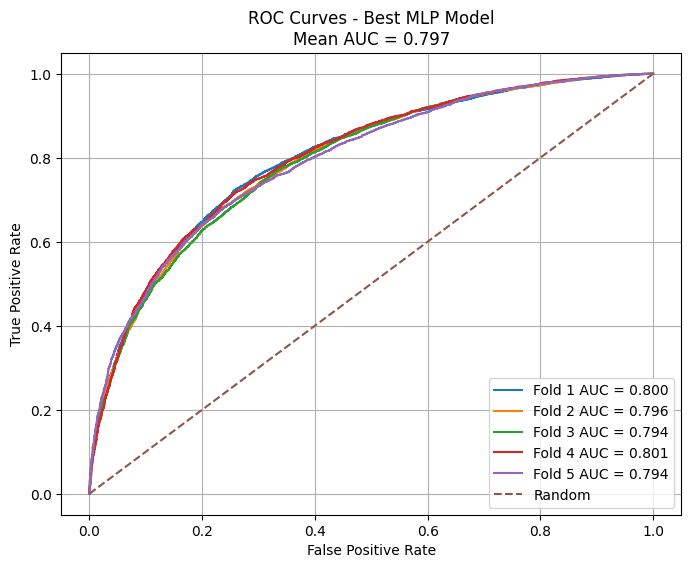

In [39]:
selected_features = ['missing_energy_magnitude', 'jet_1_pt', 'jet_1_b_tag', 'jet_2_pt', 'jet_2_b_tag', 'jet_3_pt',
    'jet_3_b_tag', 'jet_4_pt', 'jet_4_b_tag', 'm_jj', 'm_jjj', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']

best_params = {'hidden_layer_sizes': (100,), 'activation': 'relu'}

X = df_clean[selected_features]
y = df_clean["label"].astype(int)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []
auc_scores = []

plt.figure(figsize=(8, 6))


for fold, (train_index, test_index) in enumerate(cv.split(X, y), start=1):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = MLPClassifier(
        hidden_layer_sizes=best_params["hidden_layer_sizes"],
        activation=best_params["activation"],
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Fold": fold, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1 Score": f1, "ROC-AUC": roc_auc
    })

    auc_scores.append(roc_auc)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"Fold {fold} AUC = {roc_auc:.3f}"
    )

mean_auc = np.mean(auc_scores)
std_auc = np.std(auc_scores, ddof=1)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves - Best MLP Model\nMean AUC = {mean_auc:.3f}, Std AUC = {std_auc:.3f}")
plt.legend()
plt.grid()
plt.show()



In [40]:
results_df = pd.DataFrame(results)

auc_summary = pd.DataFrame({
    "Metric": ["Mean ROC-AUC", "Standard Deviation ROC-AUC"],
    "Value": [results_df["ROC-AUC"].mean(), results_df["ROC-AUC"].std()]
})

display(results_df)
display(auc_summary)


,Fold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,0.730624,0.744642,0.769510,0.756872,0.800390
1,2,0.720158,0.733866,0.763322,0.748304,0.796033
2,3,0.721761,0.735632,0.764014,0.749554,0.793778
3,4,0.712871,0.796658,0.635231,0.706845,0.800789
4,5,0.716832,0.732185,0.757397,0.744578,0.794486
